# Few dimensions analysis


## CIFAR10

In [ ]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
import os
import sys
sys.path.append(os.path.abspath(".."))

from analysis.viz import visualize_3d, tsne_3d
from metrics.retrieval import compute_retrieval
from dataset.cifar10.cifar10_dataloader_with_labels import EmbeddingsDatasetWithLabels as EmbeddingsDatasetWithLabelsCifar
from dataset.cifar10.cifar10_dataloader_with_labels import make_loaders_cifar10

import torch.nn.functional as F
import torch 
import torch.nn as nn
import wandb
import copy
import random
from torch.nn.utils import clip_grad_norm_
# Add parent directory to Python path so we can import `models.*`
seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from subspace_alignment.subspace_alignment import fit_subspace_alignment, apply_subspace_alignment, eval_subspace_alignment_mscoco, analyze_subspace_dimensions
import matplotlib.pyplot as plt



In [ ]:
# Define constants
dataset = "cifar10"  # or "flickr30k"
CLIP_MODEL = "ViT-B-16"
CLIP_PRETRAINED = "laion2b_s34b_b88k"
MODEL_TAG = f"{CLIP_MODEL}_{CLIP_PRETRAINED}"
precomputed_train_dir = f"/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_{MODEL_TAG}"
precomputed_test_dir = f"/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_{MODEL_TAG}"
device = "cuda:1" if torch.cuda.is_available() else "cpu"

In [ ]:
train_loader, test_loader = make_loaders_cifar10(batch_size=256, precomputed_train_dir=precomputed_train_dir, precomputed_test_dir=precomputed_test_dir, seed=seed, num_workers=0)

In [ ]:
#Let's get it from the training set, since it contains more samples per class and thus the average embedding will be more stable
label_to_embedding = {}
with torch.no_grad():
    for text_b, vis_b, labels in tqdm(train_loader, desc="Building label_to_embedding dict"):
        for text_emb, vis_emb, label in zip(text_b, vis_b, labels):
            label = label.item()
            if label not in label_to_embedding:
                label_to_embedding[label] = {"text": []}
                label_to_embedding[label] = text_emb

In [ ]:
def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device='cuda:1'):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)  # (D,)
    muY = Y.mean(axis=0)  # (D,)

    gap_dim = np.abs(muX - muY) 
    top_gap = np.argsort(-gap_dim)

    return normalize01(gap_dim), top_gap

In [ ]:
D_SUB_CIFAR10 = 256
d_sub = D_SUB_CIFAR10
sub_model = fit_subspace_alignment(train_loader, d_sub=d_sub)
important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(sub_model, device="cuda:1")
gap_dims, top_gap_idx = get_dims_gap(train_loader)

In [ ]:
from subspace_alignment.subspace_alignment import fit_subspace_alignment, apply_subspace_alignment, analyze_subspace_dimensions, eval_subspace_alignment_cifar10
eval_subspace_alignment_cifar10(test_loader, sub_model, labels_to_emb=label_to_embedding)

In [ ]:
plt.plot(gap_dims, label="gap per-dim |mean(text)-mean(vision)| (norm)")
plt.plot(important_joint_dims, label="subspace importance joint (norm)")
plt.title(f"CIFAR-10 ==> Gap-per-dimension vs Subspace importance (d_sub={d_sub})")
plt.xlabel("Original embedding dimension")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.5)
plt.title(f"CIFAR-10 Scatter: gap_dim vs imp_joint")
plt.xlabel("gap_dim = |mean_x - mean_y|")
plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
plt.grid(True)
plt.show()

In [ ]:
def plot_gap_importance_unified(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    # Orders
    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    # Sorted values
    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    # Left: ordered by gap
    axes[0].plot(gap_by_gap, label="Gap per dimension", color="red")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)", color="blue")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    # Right: ordered by importance
    axes[1].plot(gap_by_imp, label="Gap per dimension", color="red")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)", color="blue")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by subspace importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("Gap vs Subspace Importance (Unified Figure)", y=1.02)
    plt.tight_layout()
    plt.show()


analysis = {
    'gap_dim' : gap_dims,
    'imp_joint' : important_joint_dims
}
plot_gap_importance_unified(analysis)

### Ablation on thresholds selection

In [ ]:
import math
try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "optuna is required for Bayesian search. Install with: pip install optuna"
    ) from exc

from analysis.modality_gap import compute_gap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    v_measure_score,
)
CIFAR_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 123,
    "max_eval_batches": None,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": 10,
}

In [ ]:

def _select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)

def _clustering_metrics_two_modalities(X, Y, labels, n_clusters=10, random_state=0):
    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()
    if torch.is_tensor(labels):
        L_np = labels.detach().cpu().numpy()
    else:
        L_np = np.asarray(labels)

    emb = np.vstack([X_np, Y_np])
    true2 = np.concatenate([L_np, L_np], axis=0)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    pred = km.fit_predict(emb)

    return {
        "ARI": adjusted_rand_score(true2, pred),
        "NMI": normalized_mutual_info_score(true2, pred),
        "Homogeneity": homogeneity_score(true2, pred),
        "V-measure": v_measure_score(true2, pred),
        "cluster_labels": pred,
        "true_labels_2N": true2,
        "emb_2N": emb,
    }

def _plot_pca_2d(emb_2N, labels_2N, title, max_points=6000):
    n2 = emb_2N.shape[0]
    n = n2 // 2
    modality = np.concatenate([
        np.zeros(n, dtype=np.int32),
        np.ones(n2 - n, dtype=np.int32),
    ])

    if n2 > max_points:
        idx = np.random.RandomState(0).choice(n2, size=max_points, replace=False)
        emb_2N = emb_2N[idx]
        labels_2N = labels_2N[idx]
        modality = modality[idx]

    z = PCA(n_components=2, random_state=0).fit_transform(emb_2N)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2N[modality == 1], cmap="tab10", s=18, alpha=0.6, marker="o", label="vision"
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2N[modality == 0], cmap="tab10", s=18, alpha=0.8, marker="x", label="text"
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def eval_thresholds_cifar10(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    label_to_embedding,
    device="cuda:1",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=10,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    r_orig = {1: [], 5: [], 10: []}
    r_al = {1: [], 5: [], 10: []}
    gaps = ["RMG", "L2M", "L2I", "cosineTP"]
    gaps_orig_batches = {g: [] for g in gaps}
    gaps_al_batches = {g: [] for g in gaps}

    Xt_buf, Xv_buf, Xt_al_buf, Xv_al_buf, y_buf = [], [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Eval thresholds CIFAR10"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            labels = labels.to(device)

            Xs = X[:, idx]
            Ys = Y[:, idx]
            label_to_embedding_sel = {
               k: v.to(X.device)[idx] for k, v in label_to_embedding.items()
            }

            inputs = (Xs, Ys, labels) if direction == "text_to_vision" else (Ys, Xs, labels)
            r_orig[1].append(_to_scalar(compute_retrieval("cifar10", inputs, top_k=1, labels_to_emb=label_to_embedding_sel)))
            r_orig[5].append(_to_scalar(compute_retrieval("cifar10", inputs, top_k=5, labels_to_emb=label_to_embedding_sel)))
            r_orig[10].append(_to_scalar(compute_retrieval("cifar10", inputs, top_k=10, labels_to_emb=label_to_embedding_sel)))

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            inputs_al = (Xal_s, Yal_s, labels) if direction == "text_to_vision" else (Yal_s, Xal_s, labels)
            r_al[1].append(_to_scalar(compute_retrieval("cifar10", inputs_al, top_k=1, labels_to_emb=label_to_embedding_sel)))
            r_al[5].append(_to_scalar(compute_retrieval("cifar10", inputs_al, top_k=5, labels_to_emb=label_to_embedding_sel)))
            r_al[10].append(_to_scalar(compute_retrieval("cifar10", inputs_al, top_k=10, labels_to_emb=label_to_embedding_sel)))

            for gname in gaps:
                go = compute_gap(gname, Xs, Ys, iterations=None)
                ga = compute_gap(gname, Xal_s, Yal_s, iterations=None)
                gaps_orig_batches[gname].append(_to_scalar(go))
                gaps_al_batches[gname].append(_to_scalar(ga))

            if seen < max_cluster_samples:
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xt_al_buf.append(Xal_s[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                y_buf.append(labels[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    gaps_orig = {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()}
    gaps_al = {g: float(np.mean(v)) for g, v in gaps_al_batches.items()}

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
    }

    if len(Xt_buf) > 0:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xt_al_all = torch.cat(Xt_al_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)
        y_all = torch.cat(y_buf, dim=0)

        if direction == "text_to_vision":
            cluster_orig = _clustering_metrics_two_modalities(
                Xt_all, Xv_all, y_all, n_clusters=n_clusters, random_state=0
            )
            cluster_al = _clustering_metrics_two_modalities(
                Xt_al_all, Xv_al_all, y_all, n_clusters=n_clusters, random_state=0
            )
        else:
            cluster_orig = _clustering_metrics_two_modalities(
                Xv_all, Xt_all, y_all, n_clusters=n_clusters, random_state=0
            )
            cluster_al = _clustering_metrics_two_modalities(
                Xv_al_all, Xt_al_all, y_all, n_clusters=n_clusters, random_state=0
            )

        metrics["clustering_orig"] = {
            k: cluster_orig[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure"]
        }
        metrics["clustering_aligned"] = {
            k: cluster_al[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure"]
        }
    else:
        metrics["clustering_orig"] = None
        metrics["clustering_aligned"] = None

    return metrics

def objective_cifar10(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds_cifar10(
        imp_thr,
        gap_thr,
        test_loader,
        sub_model,
        label_to_embedding=label_to_embedding,
        device=device,
        max_eval_batches=CIFAR_SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=CIFAR_SEARCH_CFG["max_cluster_samples"],
        n_clusters=CIFAR_SEARCH_CFG["n_clusters"],
        direction=CIFAR_SEARCH_CFG["direction"],
        min_dims=CIFAR_SEARCH_CFG["min_dims"],
    )

    r_orig = metrics["retrieval_orig"][1]
    r_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r_orig + r_al) + 0.5 * (v_orig + v_al)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr("score_terms", {"r_orig": r_orig, "r_al": r_al, "v_orig": v_orig, "v_al": v_al})
    return score

sampler = optuna.samplers.TPESampler(seed=CIFAR_SEARCH_CFG["seed"])
study_cifar10 = optuna.create_study(direction="maximize", sampler=sampler)
study_cifar10.optimize(objective_cifar10, n_trials=CIFAR_SEARCH_CFG["n_trials"])

best_cifar10 = study_cifar10.best_trial
best_metrics_cifar10 = best_cifar10.user_attrs["metrics"]

print("Best thresholds (CIFAR10):")
print(f"  imp_thr={best_cifar10.params['imp_thr']:.4f} | gap_thr={best_cifar10.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics_cifar10['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics_cifar10['retrieval_orig'][1]:.4f} | aligned={best_metrics_cifar10['retrieval_aligned'][1]:.4f}")
if best_metrics_cifar10["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(
        f"  orig={best_metrics_cifar10['clustering_orig']['V-measure']:.4f} | "
        f"aligned={best_metrics_cifar10['clustering_aligned']['V-measure']:.4f}"
    )
print("Best gaps (orig):", best_metrics_cifar10["gaps_orig"])
print("Best gaps (aligned):", best_metrics_cifar10["gaps_aligned"])

top_cifar10 = sorted(study_cifar10.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top_cifar10, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )


In [ ]:

# Scatter plot: selected vs removed dimensions for the best CIFAR10 thresholds
best_idx_cifar10 = _select_dims(
    important_joint_dims,
    gap_dims,
    best_cifar10.params["imp_thr"],
    best_cifar10.params["gap_thr"],
    min_dims=CIFAR_SEARCH_CFG["min_dims"],
)

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[best_idx_cifar10] = False
plt.scatter(gap_dims[removed_mask], important_joint_dims[removed_mask], s=20, color="red", marker="x", label="Removed")
plt.scatter(gap_dims[best_idx_cifar10], important_joint_dims[best_idx_cifar10], s=24, color="blue", marker="o", label="Selected")

plt.title(
    f"CIFAR10 selected dims: {len(best_idx_cifar10)} "
    f"(imp > {best_cifar10.params['imp_thr']:.3f}, gap < {best_cifar10.params['gap_thr']:.3f})"
)
plt.xlabel("Gap")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()

def plot_search_results_cifar10(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined score")
    plt.ylabel("Importance threshold (> imp_thr)")
    plt.xlabel("Gap threshold (< gap_thr)")
    plt.title("CIFAR10 Optuna search results")
    plt.grid(True)
    plt.show()

plot_search_results_cifar10(study_cifar10)


In [ ]:

# PCA view for the best threshold selection on CIFAR10
def _collect_latent_for_plot_cifar10(
    loader,
    idx,
    model,
    device="cuda:1",
    max_samples=4000,
):
    X_buf, Y_buf, Yal_buf, labels_buf = [], [], [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(loader, desc="Collect CIFAR10 for PCA"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            Xs = X[:, idx]
            Ys = Y[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break
            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())
            labels_buf.append(labels[:b].detach().cpu())
            seen += b
            if seen >= max_samples:
                break

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    labels_all = torch.cat(labels_buf, dim=0).numpy()
    return X_all, Y_all, Yal_all, labels_all

X_all_c, Y_all_c, Yal_all_c, labels_all_c = _collect_latent_for_plot_cifar10(
    test_loader,
    best_idx_cifar10,
    sub_model,
    device=device,
    max_samples=4000,
)

emb_orig_c = torch.cat([X_all_c, Y_all_c], dim=0).numpy()
emb_al_c = torch.cat([X_all_c, Yal_all_c], dim=0).numpy()
labels_2N_c = np.concatenate([labels_all_c, labels_all_c], axis=0)

_plot_pca_2d(
    emb_orig_c,
    labels_2N_c,
    title="CIFAR10 PCA 2D (orig, best threshold subset)",
    max_points=4000,
)

_plot_pca_2d(
    emb_al_c,
    labels_2N_c,
    title="CIFAR10 PCA 2D (aligned, best threshold subset)",
    max_points=4000,
)


In [ ]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
import os
import sys
sys.path.append(os.path.abspath(".."))

from analysis.viz import visualize_3d, tsne_3d
from metrics.retrieval import compute_retrieval
from tqdm import tqdm

import torch.nn.functional as F
import torch 
import torch.nn as nn
import wandb
import copy
import random
from torch.nn.utils import clip_grad_norm_
# Add parent directory to Python path so we can import `models.*`
seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, v_measure_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from dataset.mscoco.mscoco_dataloader_with_labels import mscoco_collate_fn, make_loaders_mscoco
from subspace_alignment.subspace_alignment import fit_subspace_alignment, apply_subspace_alignment, eval_subspace_alignment_mscoco, analyze_subspace_dimensions
device = "cuda:1" if torch.cuda.is_available() else "cpu"

dataset = "mscoco"
CLIP_MODEL = "ViT-B-16"
CLIP_PRETRAINED = "laion2b_s34b_b88k"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"
precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{MODEL_NAME}/precomputed_train2017_clip"
precomputed_dir_test = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{MODEL_NAME}/precomputed_val2017_clip"

In [ ]:
def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device='cuda:1'):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)  # (D,)
    muY = Y.mean(axis=0)  # (D,)

    gap_dim = np.abs(muX - muY) 
    top_gap = np.argsort(-gap_dim)

    return normalize01(gap_dim), top_gap

In [ ]:
train_loader, test_loader = make_loaders_mscoco(
    precomputed_dir=precomputed_dir,
    precomputed_dir_test=precomputed_dir_test,
    batch_size=256
)

### Dims analysis

In [ ]:
D_SUB_MSCOCO_IMAGENET = 256
d_sub = D_SUB_MSCOCO_IMAGENET
sub_model = fit_subspace_alignment(train_loader,n_fit=10_000, d_sub=d_sub, device=device)
important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(sub_model, device="cuda:1")
gap_dims, top_gap_idx = get_dims_gap(train_loader)


In [ ]:
# Plot  plt.figure(figsize=(10, 4))
plt.plot(gap_dims, label="gap per-dim |mean(text)-mean(vision)| (norm)")
plt.plot(important_joint_dims, label="subspace importance joint (norm)")
plt.title(f"MSCOCO ==> Gap-per-dimension vs Subspace importance (d_sub={d_sub})")
plt.xlabel("Original embedding dimension")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.5)
plt.title(f"MSCOCO Scatter: gap_dim vs imp_joint")
plt.xlabel("gap_dim = |mean_x - mean_y|")
plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
plt.grid(True)
plt.show()

In [ ]:
def plot_gap_importance_unified(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    # Orders
    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    # Sorted values
    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    # Left: ordered by gap
    axes[0].plot(gap_by_gap, label="Gap per dimension", color="red")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)", color="blue")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    # Right: ordered by importance
    axes[1].plot(gap_by_imp, label="Gap per dimension", color="red")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)", color="blue")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by subspace importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("Gap vs Subspace Importance (Unified Figure)", y=1.02)
    plt.tight_layout()
    plt.show()


analysis = {
    'gap_dim' : gap_dims,
    'imp_joint' : important_joint_dims
}
plot_gap_importance_unified(analysis)

### Ablation on thresholds selection

In [ ]:
import math
try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "optuna is required for Bayesian search. Install with: pip install optuna"
    ) from exc

from analysis.modality_gap import compute_gap
from metrics.clustering import clustering_metrics_two_modalities_multilabel_mscoco

SEARCH_CFG = {
    "n_trials": 100,
    "seed": 123,
    "max_eval_batches": None,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "label_mode": "primary",
    "direction": "text_to_vision",
    "n_clusters": 78,
}

In [ ]:
def _labels_batch_to_list(labels_batch):
    if torch.is_tensor(labels_batch):
        return [labels_batch[i] for i in range(labels_batch.shape[0])]
    if isinstance(labels_batch, np.ndarray):
        return [labels_batch[i] for i in range(labels_batch.shape[0])]
    if isinstance(labels_batch, (list, tuple)):
        return list(labels_batch)
    return [labels_batch]

def _select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)

def eval_thresholds(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    device="cuda:1",
    max_eval_batches=None,
    max_cluster_samples=3000,
    label_mode="primary",
    n_clusters=None,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    r_orig = {1: [], 5: [], 10: []}
    r_al = {1: [], 5: [], 10: []}
    gaps = ["RMG", "L2M", "L2I", "cosineTP"]
    gaps_orig_batches = {g: [] for g in gaps}
    gaps_al_batches = {g: [] for g in gaps}

    Xt_buf, Xv_buf, Xv_al_buf, y_buf = [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Eval thresholds"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "text_to_vision":
                X, Y = X, Y
            elif direction == "vision_to_text":
                X, Y = Y, X

            Xs = X[:, idx]
            Ys = Y[:, idx]

            r_orig[1].append(_to_scalar(compute_retrieval("mscoco", (Xs, Ys), top_k=1)))
            r_orig[5].append(_to_scalar(compute_retrieval("mscoco", (Xs, Ys), top_k=5)))
            r_orig[10].append(_to_scalar(compute_retrieval("mscoco", (Xs, Ys), top_k=10)))

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            r_al[1].append(_to_scalar(compute_retrieval("mscoco", (Xal_s, Yal_s), top_k=1)))
            r_al[5].append(_to_scalar(compute_retrieval("mscoco", (Xal_s, Yal_s), top_k=5)))
            r_al[10].append(_to_scalar(compute_retrieval("mscoco", (Xal_s, Yal_s), top_k=10)))

            for gname in gaps:
                go = compute_gap(gname, Xs, Ys, iterations=None)
                ga = compute_gap(gname, Xal_s, Yal_s, iterations=None)
                gaps_orig_batches[gname].append(_to_scalar(go))
                gaps_al_batches[gname].append(_to_scalar(ga))

            if seen < max_cluster_samples:
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                y_buf.extend(_labels_batch_to_list(labels)[:b])
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    gaps_orig = {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()}
    gaps_al = {g: float(np.mean(v)) for g, v in gaps_al_batches.items()}

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
    }

    if len(Xt_buf) > 0:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)

        cluster_orig = clustering_metrics_two_modalities_multilabel_mscoco(
            Xt_all, Xv_all, y_buf, n_clusters=n_clusters, random_state=0, label_mode=label_mode
        )
        cluster_al = clustering_metrics_two_modalities_multilabel_mscoco(
            Xt_all, Xv_al_all, y_buf, n_clusters=n_clusters, random_state=0, label_mode=label_mode
        )

        metrics["clustering_orig"] = {
            k: cluster_orig[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters", "n_classes", "label_mode"]
        }
        metrics["clustering_aligned"] = {
            k: cluster_al[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters", "n_classes", "label_mode"]
        }
    else:
        metrics["clustering_orig"] = None
        metrics["clustering_aligned"] = None

    return metrics

def objective(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds(
        imp_thr,
        gap_thr,
        test_loader,
        sub_model,
        device=device,
        max_eval_batches=SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=SEARCH_CFG["max_cluster_samples"],
        label_mode=SEARCH_CFG["label_mode"],
        n_clusters=SEARCH_CFG["n_clusters"],
        direction=SEARCH_CFG["direction"],
        min_dims=SEARCH_CFG["min_dims"],
    )

    r_orig = metrics["retrieval_orig"][1]
    r_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r_orig + r_al) + 0.5 * (v_orig + v_al)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr("score_terms", {"r_orig": r_orig, "r_al": r_al, "v_orig": v_orig, "v_al": v_al})
    return score

sampler = optuna.samplers.TPESampler(seed=SEARCH_CFG["seed"])
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=SEARCH_CFG["n_trials"])

best = study.best_trial
best_metrics = best.user_attrs["metrics"]

print("Best thresholds:")
print(f"  imp_thr={best.params['imp_thr']:.4f} | gap_thr={best.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics['retrieval_orig'][1]:.4f} | aligned={best_metrics['retrieval_aligned'][1]:.4f}")
if best_metrics["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(f"  orig={best_metrics['clustering_orig']['V-measure']:.4f} | aligned={best_metrics['clustering_aligned']['V-measure']:.4f}")
print("Best gaps (orig):", best_metrics["gaps_orig"])

print("Best gaps (aligned):", best_metrics["gaps_aligned"])

# Optional: inspect top trials
top = sorted(study.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )

In [ ]:
# Create 2d plot y axis joint importance, x axes gap. All the dimensions are red x, excluding the ones selected by the best thresholds, which are blue circles. 
gap_dim = best_metrics["gaps_orig"]["RMG"]
imp_joint = important_joint_dims
imp_thr = best.params["imp_thr"]
gap_thr = best.params["gap_thr"]    
filter_mask = (important_joint_dims >= imp_thr) & (gap_dims <= gap_thr)
filtered_gap_dim = gap_dims[filter_mask]
filtered_imp_joint = important_joint_dims[filter_mask]

plt.figure(figsize=(6, 5))
plt.scatter(analysis["gap_dim"], analysis["imp_joint"], s=8, alpha=0.2, label="All dimensions")

selected_idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=SEARCH_CFG["min_dims"])
# x red marker on not selected dimensions
for i in range(len(gap_dims)):
    if i in selected_idx:
        continue
    else:
        plt.scatter(gap_dims[i], important_joint_dims[i], s=20, color="red", marker="x", )

plt.title(f"{len(selected_idx)} Selected dimensions by thresholds (imp_thr={imp_thr:.3f}, gap_thr={gap_thr:.3f})")
plt.xlabel("Gap (RMG)")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()  


In [ ]:
# Create the 2d plot of the search results with x red on the removed dims
def plot_search_results(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined Score")
    plt.ylabel("Importance Threshold ( > imp_thr)")
    plt.xlabel("Gap Threshold ( < gap_thr)")
    plt.title("Optuna Search Results: imp_thr vs gap_thr")
    plt.grid(True)
    plt.show()

plot_search_results(study)

In [ ]:
# Latent space visualization with multi-label blend
from analysis.viz import plot_pca_2d_mscoco_multilabel_blend

def _collect_latent_for_plot(
    loader,
    idx,
    model,
    device="cuda:1",
    max_samples=4000,
    direction="text_to_vision",
    ):
    X_buf, Y_buf, Yal_buf = [], [], []
    labels_all = []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(loader, desc="Collect for PCA"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "text_to_vision":
                X, Y = X, Y
            elif direction == "vision_to_text":
                X, Y = Y, X

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)
            Xs = X[:, idx]
            Ys = Y[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break
            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())
            labels_all.extend(_labels_batch_to_list(labels)[:b])
            seen += b
            if seen >= max_samples:
                break
    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    return X_all, Y_all, Yal_all, labels_all

best_idx = _select_dims(
    important_joint_dims,
    gap_dims,
    best.params["imp_thr"],
    best.params["gap_thr"],
    min_dims=SEARCH_CFG["min_dims"],
)

X_all, Y_all, Yal_all, labels_all = _collect_latent_for_plot(
    test_loader,
    best_idx,
    sub_model,
    device=device,
    max_samples=4000,
    direction=SEARCH_CFG["direction"],
 )

emb_orig = torch.cat([X_all, Y_all], dim=0).numpy()
emb_al = torch.cat([X_all, Yal_all], dim=0).numpy()

plot_pca_2d_mscoco_multilabel_blend(
    emb_2N=emb_orig,
    labels_per_sample=labels_all,
    title="PCA 2D (orig, multi-label blend)",
    max_points=4000,
    max_classes_to_color=20,
 )

plot_pca_2d_mscoco_multilabel_blend(
    emb_2N=emb_al,
    labels_per_sample=labels_all,
    title="PCA 2D (aligned, multi-label blend)",
    max_points=4000,
    max_classes_to_color=20,
 )

## Mscoco with imagenet labels

In [1]:
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import DataLoader

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    v_measure_score,
)
import sys
import os
sys.path.append(os.path.abspath(".."))
from dataset.mscoco.mscoco_dataloader_with_imagenet_labels import (
MSCOCOEmbeddingsDatasetWithImageNetLabels,
mscoco_imagenet_collate_fn,
)

try:
    import optuna
except ImportError as exc:
    raise ImportError("optuna is required for Bayesian search. Install with: pip install optuna") from exc

from analysis.modality_gap import compute_gap
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)

from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_mscoco_imagenet_labels
import random

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 123
seed = SEED
g = torch.Generator().manual_seed(seed)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda:1" if torch.cuda.is_available() else "cpu"
dataset_name = "mscoco_imagenet_labels"
CLIP_MODEL = "ViT-bigG-14"
CLIP_PRETRAINED = "laion2b_s39b_b160k"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"
precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{MODEL_NAME}/precomputed_train2017_clip_imagenet"
precomputed_dir_test = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{MODEL_NAME}/precomputed_val2017_clip_imagenet"

/opt/anaconda3/envs/few_dim_modalitygap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Filtering Procedure
Keep in training set only the test classes that have have in the training set at least 10 samples.

In [2]:
ds_train = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    precomputed_dir,
    split_name="train_shard",
    return_label_name=False,
)

ds_test = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    precomputed_dir_test,
    split_name="val_shard",
    return_label_name=False,
)


def _count_labels(dataset):
    counts = {}
    for i in range(len(dataset)):
        _, _, y = dataset[i]
        y = int(y.item()) if torch.is_tensor(y) else int(y)
        counts[y] = counts.get(y, 0) + 1
    return counts


train_counts = _count_labels(ds_train)
test_counts = _count_labels(ds_test)

test_classes = set(test_counts.keys())
keep_classes = {c for c in test_classes if train_counts.get(c, 0) >= 10}

train_indices = [
    i for i in range(len(ds_train))
    if int(ds_train[i][2].item()) in keep_classes
]

test_indices = [
    i for i in range(len(ds_test))
    if int(ds_test[i][2].item()) in keep_classes
]

filtered_train = torch.utils.data.Subset(ds_train, train_indices)
filtered_test = torch.utils.data.Subset(ds_test, test_indices)


def _count_labels_subset(subset):
    counts = {}
    for i in range(len(subset)):
        _, _, y = subset[i]
        y = int(y.item()) if torch.is_tensor(y) else int(y)
        counts[y] = counts.get(y, 0) + 1
    return counts


filtered_train_counts = _count_labels_subset(filtered_train)
filtered_test_counts = _count_labels_subset(filtered_test)

train_classes = set(filtered_train_counts.keys())
test_classes = set(filtered_test_counts.keys())

print(f"Kept classes (train >= 10 & in test): {len(keep_classes)}")
print(f"Train classes after filter: {len(train_classes)}")
print(f"Test classes after filter: {len(test_classes)}")
print(f"Train samples after filter: {len(filtered_train)}")
print(f"Test samples after filter: {len(filtered_test)}")

assert train_classes == test_classes, "Train/test class mismatch after filtering"

batch_size = 256
N_CLUSTERS_MSCOCO_IMAGENET = len(train_classes)

train_loader = DataLoader(
    filtered_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)

test_loader = DataLoader(
    filtered_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)

[Loaded COCO ImageNet] 118287 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-bigG-14___laion2b_s39b_b160k/precomputed_train2017_clip_imagenet | vision_emb shape=(118287, 1280)
[Loaded COCO ImageNet] 5000 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-bigG-14___laion2b_s39b_b160k/precomputed_val2017_clip_imagenet | vision_emb shape=(5000, 1280)
Kept classes (train >= 10 & in test): 517
Train classes after filter: 517
Test classes after filter: 517
Train samples after filter: 113777
Test samples after filter: 4963


In [3]:
# %% [code]
def get_dims_gap_imagenet(loader, max_samples=20_000, device="cuda:1"):
    """
    Compute normalized per-dimension gap:
        |mean(text_dim) - mean(vision_dim)|
    over a subset of samples.
    """
    x_sum = None
    y_sum = None
    seen = 0

    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc="Compute per-dim gap"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            b = X.shape[0]
            if x_sum is None:
                x_sum = X.sum(dim=0)
                y_sum = Y.sum(dim=0)
            else:
                x_sum += X.sum(dim=0)
                y_sum += Y.sum(dim=0)

            seen += b
            if seen >= max_samples:
                break

    mean_x = x_sum / max(seen, 1)
    mean_y = y_sum / max(seen, 1)

    gap_dim = (mean_x - mean_y).abs().detach().cpu().numpy()
    gap_dim = gap_dim / (gap_dim.max() + 1e-12)

    top_gap_idx = np.argsort(-gap_dim)
    return gap_dim, top_gap_idx

### Gap-per-dimension vs subspace importance

In [4]:
D_SUB_MSCOCO_IMAGENET = 128
d_sub = D_SUB_MSCOCO_IMAGENET

sub_model = fit_subspace_alignment(
    train_loader,
    d_sub=d_sub,
    device=device,
)

important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(
    sub_model,
    device=device,
)

gap_dims, top_gap_idx = get_dims_gap_imagenet(
    train_loader,
    max_samples=20_000,
    device=device,
)

Collected 10000 samples of dimension 1280, these will be used to fit the subspace alignment model with d_sub=128.


Compute per-dim gap:  18%|█▊        | 78/445 [00:00<00:01, 342.06it/s]


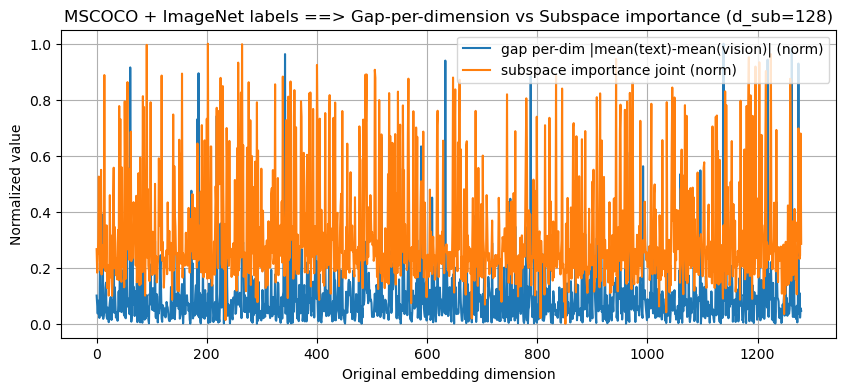

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(gap_dims, label="gap per-dim |mean(text)-mean(vision)| (norm)")
plt.plot(important_joint_dims, label="subspace importance joint (norm)")
plt.title(f"MSCOCO + ImageNet labels ==> Gap-per-dimension vs Subspace importance (d_sub={d_sub})")
plt.xlabel("Original embedding dimension")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend()
plt.show()

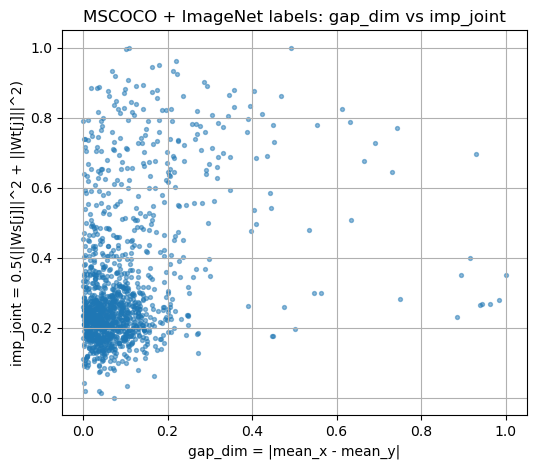

In [6]:
# %% [code]
plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.5)
plt.title("MSCOCO + ImageNet labels: gap_dim vs imp_joint")
plt.xlabel("gap_dim = |mean_x - mean_y|")
plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
plt.grid(True)
plt.show()

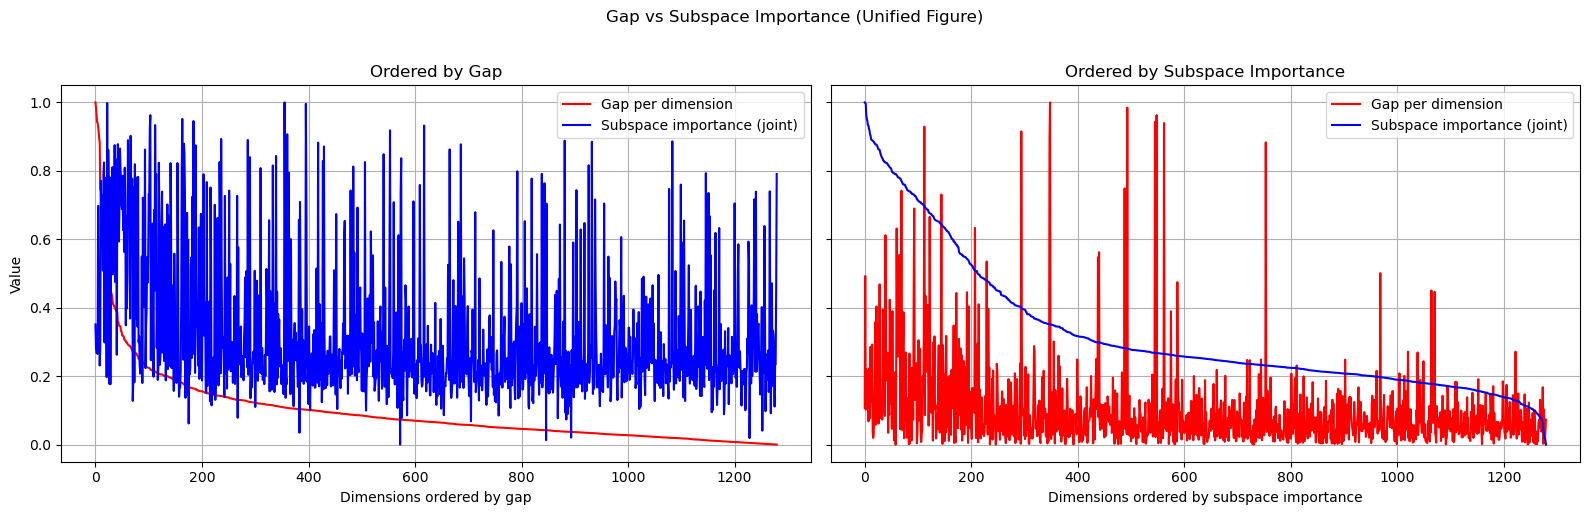

In [7]:
# %% [code]
def plot_gap_importance_unified(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    axes[0].plot(gap_by_gap, label="Gap per dimension", color="red")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)", color="blue")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(gap_by_imp, label="Gap per dimension", color="red")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)", color="blue")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by subspace importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("Gap vs Subspace Importance (Unified Figure)", y=1.02)
    plt.tight_layout()
    plt.show()


analysis = {
    "gap_dim": gap_dims,
    "imp_joint": important_joint_dims,
}
plot_gap_importance_unified(analysis)

### Ablation on threshold selection

In [8]:
SEARCH_CFG_IMAGENET = {
    "n_trials": 100,
    "seed": 123,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
}

In [9]:
def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)

In [10]:
# %% [code]
def _select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)


def eval_thresholds_mscoco_imagenet(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    device="cuda:1",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=None,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    # 1) Accumulate full eval set first (CPU buffers to avoid GPU memory pressure)
    X_buf, Y_buf, y_buf = [], [], []
    rmg_batches = {'orig': [], 'aligned': []}
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Accumulate MSCOCO-ImageNet test set"):
            X = F.normalize(text_b, dim=-1).cpu()
            Y = F.normalize(vis_b, dim=-1).cpu()
            labels = labels if torch.is_tensor(labels) else torch.as_tensor(labels)
            labels = labels.cpu()

            if direction == "vision_to_text":
                X, Y = Y, X

            Xs_batch = X[:, idx]
            Ys_batch = Y[:, idx]
            rmg_batches['orig'].append(float(_to_scalar(compute_gap('RMG', Xs_batch, Ys_batch, iterations=None))))

            xb = X.to(device)
            yb = Y.to(device)
            Xn, Yn, Yaln = apply_subspace_alignment(xb, yb, sub_model, renorm=True)
            Xal_s_batch = Xn[:, idx]
            Yal_s_batch = Yaln[:, idx]
            rmg_batches['aligned'].append(
                float(_to_scalar(compute_gap('RMG', Xal_s_batch, Yal_s_batch, iterations=None)))
            )

            X_buf.append(X)
            Y_buf.append(Y)
            y_buf.append(labels)

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    if len(X_buf) == 0:
        raise ValueError("No samples were accumulated from test_loader.")

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    y_all = torch.cat(y_buf, dim=0)

    # Selected subspace (original)
    Xs = X_all[:, idx]
    Ys = Y_all[:, idx]

    # 2) Metrics on full accumulated set (no per-batch averaging)
    retrieval_orig = {
        1: float(_to_scalar(compute_retrieval(dataset_name, (Xs, Ys), top_k=1))),
        5: float(_to_scalar(compute_retrieval(dataset_name, (Xs, Ys), top_k=5))),
        10: float(_to_scalar(compute_retrieval(dataset_name, (Xs, Ys), top_k=10))),
    }

    # Avoid RMG due to CUDA memory constraints
    gaps = ["L2M", "L2I", "cosineTP"]
    gaps_orig = {g: float(_to_scalar(compute_gap(g, Xs, Ys, iterations=None))) for g in gaps}

    # 3) Alignment on full set (chunked) then metrics
    N = X_all.shape[0]
    align_bs = 1024
    Xal_s_chunks, Yal_s_chunks = [], []

    with torch.no_grad():
        for s in range(0, N, align_bs):
            e = min(s + align_bs, N)
            xb = X_all[s:e].to(device)
            yb = Y_all[s:e].to(device)

            Xn, Yn, Yaln = apply_subspace_alignment(xb, yb, sub_model, renorm=True)
            Xal_s_chunks.append(Xn[:, idx].detach().cpu())
            Yal_s_chunks.append(Yaln[:, idx].detach().cpu())

    Xal_s_all = torch.cat(Xal_s_chunks, dim=0)
    Yal_s_all = torch.cat(Yal_s_chunks, dim=0)

    retrieval_aligned = {
        1: float(_to_scalar(compute_retrieval(dataset_name, (Xal_s_all, Yal_s_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval(dataset_name, (Xal_s_all, Yal_s_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval(dataset_name, (Xal_s_all, Yal_s_all), top_k=10))),
    }

    gaps_aligned = {
        g: float(_to_scalar(compute_gap(g, Xal_s_all, Yal_s_all, iterations=None))) for g in gaps
    }

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_aligned,
        "mean_rmg_over_batches": {k: float(np.mean(v)) for k, v in rmg_batches.items()},
    }

    # 4) Clustering metrics on accumulated set (optionally capped)
    if n_clusters is None:
        raise ValueError("n_clusters must be specified for clustering evaluation with ImageNet labels")

    if max_cluster_samples is not None and Xs.shape[0] > max_cluster_samples:
        sel = torch.randperm(Xs.shape[0])[:max_cluster_samples]
        Xt_c = Xs[sel]
        Xv_c = Ys[sel]
        Xt_al_c = Xal_s_all[sel]
        Xv_al_c = Yal_s_all[sel]
        y_c = y_all[sel]
    else:
        Xt_c = Xs
        Xv_c = Ys
        Xt_al_c = Xal_s_all
        Xv_al_c = Yal_s_all
        y_c = y_all

    cluster_orig = clustering_metrics_two_modalities_mscoco_imagenet_labels(
        Xt_c, Xv_c, y_c, n_clusters=n_clusters, random_state=0
    )
    cluster_al = clustering_metrics_two_modalities_mscoco_imagenet_labels(
        Xt_al_c, Xv_al_c, y_c, n_clusters=n_clusters, random_state=0
    )

    metrics["clustering_orig"] = {
        k: cluster_orig[k] for k in ["ARI", "NMI", "Homogeneity", "V-measure"]
    }
    metrics["clustering_aligned"] = {
        k: cluster_al[k] for k in ["ARI", "NMI", "Homogeneity", "V-measure"]
    }

    return metrics

In [11]:
# %% [code]
def objective_imagenet(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds_mscoco_imagenet(
        imp_thr=imp_thr,
        gap_thr=gap_thr,
        test_loader=test_loader,
        sub_model=sub_model,
        device=device,
        max_eval_batches=SEARCH_CFG_IMAGENET["max_eval_batches"],
        max_cluster_samples=SEARCH_CFG_IMAGENET["max_cluster_samples"],
        n_clusters=N_CLUSTERS_MSCOCO_IMAGENET,
        direction=SEARCH_CFG_IMAGENET["direction"],
        min_dims=SEARCH_CFG_IMAGENET["min_dims"],
    )

    r_orig = metrics["retrieval_orig"][1]
    r_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r_orig + r_al) + 0.5 * (v_orig + v_al)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr("score_terms", {"r_orig": r_orig, "r_al": r_al, "v_orig": v_orig, "v_al": v_al})
    return score

In [12]:
# %% [code]
sampler = optuna.samplers.TPESampler(seed=SEARCH_CFG_IMAGENET["seed"])
study_imagenet = optuna.create_study(direction="maximize", sampler=sampler)
study_imagenet.optimize(objective_imagenet, n_trials=SEARCH_CFG_IMAGENET["n_trials"])

best_imagenet = study_imagenet.best_trial
best_metrics_imagenet = best_imagenet.user_attrs["metrics"]

print("Best thresholds:")
print(f"  imp_thr={best_imagenet.params['imp_thr']:.4f} | gap_thr={best_imagenet.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics_imagenet['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics_imagenet['retrieval_orig'][1]:.4f} | aligned={best_metrics_imagenet['retrieval_aligned'][1]:.4f}")
if best_metrics_imagenet["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(f"  orig={best_metrics_imagenet['clustering_orig']['V-measure']:.4f} | aligned={best_metrics_imagenet['clustering_aligned']['V-measure']:.4f}")
print("Best gaps (orig):", best_metrics_imagenet["gaps_orig"])

print("Best gaps (aligned):", best_metrics_imagenet["gaps_aligned"])

# Optional: inspect top trials
top = sorted(study_imagenet.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )

[I 2026-03-30 16:42:58,197] A new study created in memory with name: no-name-c98f3dc9-46ce-4f39-b9ab-3e8d777fdb28
Accumulate MSCOCO-ImageNet test set: 100%|██████████| 20/20 [00:00<00:00, 106.32it/s]
[I 2026-03-30 16:43:00,286] Trial 0 finished with value: 0.7802215280836373 and parameters: {'imp_thr': 0.6964691855978616, 'gap_thr': 0.28613933495037946}. Best is trial 0 with value: 0.7802215280836373.
Accumulate MSCOCO-ImageNet test set: 100%|██████████| 20/20 [00:00<00:00, 197.82it/s]
[I 2026-03-30 16:43:06,884] Trial 1 finished with value: 1.1091670341023732 and parameters: {'imp_thr': 0.2268514535642031, 'gap_thr': 0.5513147690828912}. Best is trial 1 with value: 1.1091670341023732.
Accumulate MSCOCO-ImageNet test set: 100%|██████████| 20/20 [00:00<00:00, 243.12it/s]
[I 2026-03-30 16:43:08,647] Trial 2 finished with value: 0.7833667511960616 and parameters: {'imp_thr': 0.7194689697855631, 'gap_thr': 0.42310646012446096}. Best is trial 1 with value: 1.1091670341023732.
Accumulate MSC

Best thresholds:
  imp_thr=0.1374 | gap_thr=0.9987
  n_dims=1203
Best metrics (retrieval@1):
  orig=0.4677 | aligned=0.3887
Best metrics (V-measure):
  orig=0.6867 | aligned=0.7151
Best gaps (orig): {'L2M': 0.5868661403656006, 'L2I': 1.0712039470672607, 'cosineTP': 0.4062404930591583}
Best gaps (aligned): {'L2M': 0.18454037606716156, 'L2I': 0.7768473029136658, 'cosineTP': 0.6849890351295471}
Top 1: score=1.1291 imp=0.137 gap=0.999 dims=1203 r1_o=0.4677 r1_a=0.3887 v_o=0.6867 v_a=0.7151
Top 2: score=1.1276 imp=0.046 gap=0.931 dims=1269 r1_o=0.4713 r1_a=0.3887 v_o=0.6826 v_a=0.7127
Top 3: score=1.1275 imp=0.099 gap=0.978 dims=1257 r1_o=0.4711 r1_a=0.3891 v_o=0.6853 v_a=0.7096
Top 4: score=1.1273 imp=0.130 gap=0.938 dims=1213 r1_o=0.4691 r1_a=0.3887 v_o=0.6873 v_a=0.7096
Top 5: score=1.1267 imp=0.033 gap=0.963 dims=1273 r1_o=0.4713 r1_a=0.3885 v_o=0.6828 v_a=0.7108


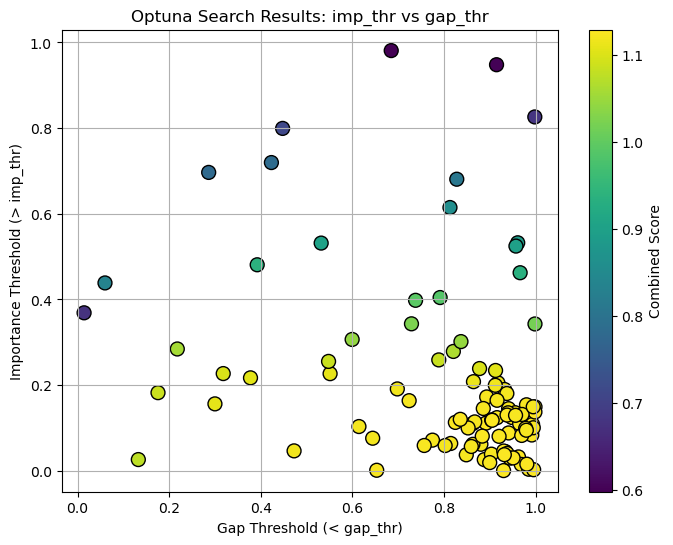

In [13]:
# %% [code]
def plot_search_results(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials if t.value is not None]
    gap_thrs = [t.params["gap_thr"] for t in study.trials if t.value is not None]
    scores = [t.value for t in study.trials if t.value is not None]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined Score")
    plt.ylabel("Importance Threshold (> imp_thr)")
    plt.xlabel("Gap Threshold (< gap_thr)")
    plt.title("Optuna Search Results: imp_thr vs gap_thr")
    plt.grid(True)
    plt.show()


plot_search_results(study_imagenet)

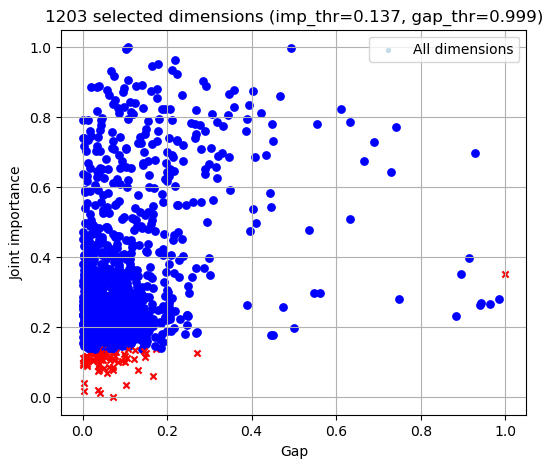

In [14]:
# %% [code]
imp_thr = best_imagenet.params["imp_thr"]
gap_thr = best_imagenet.params["gap_thr"]

selected_idx_imagenet = _select_dims(
    important_joint_dims,
    gap_dims,
    imp_thr,
    gap_thr,
    min_dims=SEARCH_CFG_IMAGENET["min_dims"],
)

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

for i in range(len(gap_dims)):
    if i in selected_idx_imagenet:
        plt.scatter(gap_dims[i], important_joint_dims[i], s=28, color="blue", marker="o")
    else:
        plt.scatter(gap_dims[i], important_joint_dims[i], s=20, color="red", marker="x")

plt.title(
    f"{len(selected_idx_imagenet)} selected dimensions "
    f"(imp_thr={imp_thr:.3f}, gap_thr={gap_thr:.3f})"
)
plt.xlabel("Gap")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
# %% [code]
def _collect_latent_for_plot_mscoco_imagenet(
    loader,
    idx,
    model,
    device="cuda:1",
    max_samples=4000,
    direction="text_to_vision",
):
    X_buf, Y_buf, Yal_buf, labels_buf = [], [], [], []
    seen = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(loader, desc="Collect MSCOCO-ImageNet for PCA"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            labels = labels.to(device) if torch.is_tensor(labels) else torch.as_tensor(labels, device=device)

            if direction == "vision_to_text":
                X, Y = Y, X

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            Xs = Xn[:, idx]
            Ys = Yn[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break

            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())
            labels_buf.append(labels[:b].detach().cpu())

            seen += b
            if seen >= max_samples:
                break

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    labels_all = torch.cat(labels_buf, dim=0).numpy()

    return X_all, Y_all, Yal_all, labels_all

In [16]:
def _plot_pca_2d(emb_2N, labels_2N, title, max_points=6000):
    """
    PCA 2D veloce per visualizzare cluster/label (2N punti).
    Marker:
      - text: 'x'
      - vision: 'o'
    """
    n2 = emb_2N.shape[0]
    n = n2 // 2
    modality = np.concatenate([
        np.zeros(n, dtype=np.int32),          # text (first N)
        np.ones(n2 - n, dtype=np.int32)       # vision (second N)
    ])

    if n2 > max_points:
        idx = np.random.RandomState(0).choice(n2, size=max_points, replace=False)
        emb_2N = emb_2N[idx]
        labels_2N = labels_2N[idx]
        modality = modality[idx]

    pca = PCA(n_components=2, random_state=0)
    z = pca.fit_transform(emb_2N)

    plt.figure(figsize=(6, 5))

    # same colormap for labels, different marker for modality
    sc_vis = plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2N[modality == 1], s=20, marker='o', alpha=0.75, label='vision'
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2N[modality == 0], s=20, marker='x', alpha=0.75,
        cmap=sc_vis.cmap, norm=sc_vis.norm, label='text'
    )

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(loc="best")
    plt.colorbar(sc_vis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

Collect MSCOCO-ImageNet for PCA:  75%|███████▌  | 15/20 [00:00<00:00, 208.69it/s]


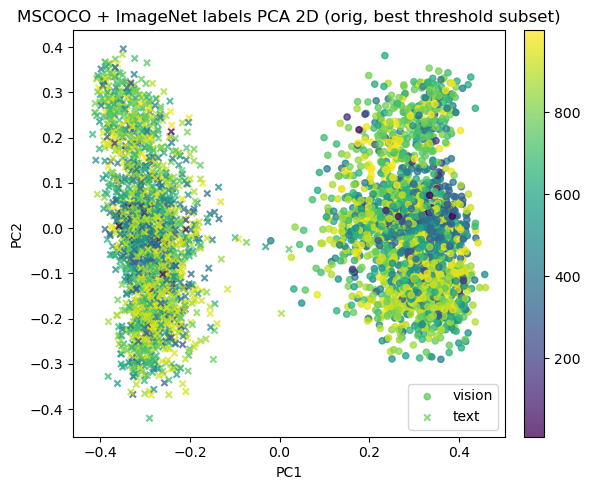

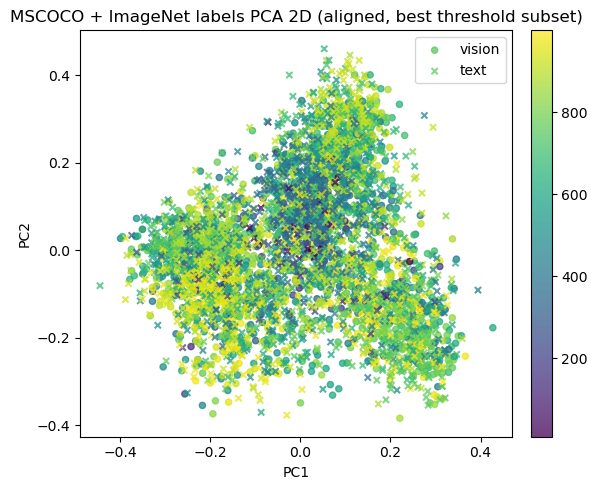

In [17]:
# %% [code]
X_all_i, Y_all_i, Yal_all_i, labels_all_i = _collect_latent_for_plot_mscoco_imagenet(
    test_loader,
    selected_idx_imagenet,
    sub_model,
    device=device,
    max_samples=4000,
    direction=SEARCH_CFG_IMAGENET["direction"],
)

emb_orig_i = torch.cat([X_all_i, Y_all_i], dim=0).numpy()
emb_al_i = torch.cat([X_all_i, Yal_all_i], dim=0).numpy()
labels_2N_i = np.concatenate([labels_all_i, labels_all_i], axis=0)

_plot_pca_2d(
    emb_orig_i,
    labels_2N_i,
    title="MSCOCO + ImageNet labels PCA 2D (orig, best threshold subset)",
    max_points=4000,
)

_plot_pca_2d(
    emb_al_i,
    labels_2N_i,
    title="MSCOCO + ImageNet labels PCA 2D (aligned, best threshold subset)",
    max_points=4000,
)

## Flickr30K

### Constants

In [ ]:
import sys
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))

from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)

from dataset.flickr30k.dataloader_embeddings_with_labels import EmbeddingsDatasetWithLabels
from dataset.flickr30k.flickr_imagenet_utils import original_idx2class
from metrics.retrieval import retrieval
from analysis.modality_gap import compute_gap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    v_measure_score,
)
from metrics.clustering import _clustering_metrics_two_modalities_flickr30k
import random
import numpy as np
import torch

seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


In [ ]:
# Define constants
dataset = "flickr30k"
CLIP_MODEL = "ViT-bigG-14"
CLIP_PRETRAINED = "laion2b_s39b_b160k"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"
precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/{MODEL_NAME}"
device = "cuda:1" if torch.cuda.is_available() else "cpu"

In [ ]:
def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda:1"):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)

    gap_dim = np.abs(muX - muY)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap

In [ ]:
# Let's get the data
precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/{MODEL_NAME}"
dataset = EmbeddingsDatasetWithLabels(precomputed_dir=precomputed_dir, split_name="flickr30k")

### Filter out data construct dataloaders
We need to filter out the classes with very few samples.

In [ ]:
### Given the train_loader and the test_loader, discover how many unique labels are in the dataset, and how many samples per label. Plot the distribution of samples per label as a histogram.
def analyze_label_distribution(loader):
    label_counts = {}

    for batch in tqdm(loader, desc="Analyzing label distribution"):
        # Works for both Dataset samples and DataLoader batches
        if isinstance(batch, (list, tuple)) and len(batch) == 3:
            _, _, labels = batch
        else:
            continue

        if torch.is_tensor(labels):
            if labels.ndim == 0:  # single sample label (Dataset iteration)
                labels_iter = [int(labels.item())]
            else:  # batched labels (DataLoader iteration)
                labels_iter = labels.detach().cpu().view(-1).tolist()
        elif isinstance(labels, (list, tuple, np.ndarray)):
            labels_iter = np.asarray(labels).reshape(-1).tolist()
        else:
            labels_iter = [int(labels)]

        for lab in labels_iter:
            label_counts[lab] = label_counts.get(lab, 0) + 1

    return label_counts

label_counts = analyze_label_distribution(dataset)
print(f"Unique labels: {len(label_counts)}")
print(f"Total samples: {sum(label_counts.values())}")

# Histogram: distribution of "samples per label"
counts = list(label_counts.values())
plt.figure(figsize=(10, 5))
plt.hist(counts, bins=30, edgecolor="black")
plt.xlabel("Samples per label")
plt.ylabel("Number of labels")
plt.title("Flickr30k label frequency distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()



In [ ]:
# We should make sure to filter out classes that have too few samples, otherwise the classifier will struggle to learn. 
# Let's set a threshold of 1% of dataset total length as samples per class constraint.
# threshold = int(0.01 * len(dataset))
threshold = 10
print(f"Filtering out classes with less than {threshold} samples...")
class_counts = {}
for _, _, label in dataset:
    if label.item() not in class_counts:
        class_counts[label.item()] = 0
    class_counts[label.item()] += 1
    
filtered_classes = {cls for cls, count in class_counts.items() if count >= threshold}
print(f"Number of classes after filtering: {len(filtered_classes)}")
filtered_indices = [i for i, (_,_, label) in enumerate(dataset) if label.item() in filtered_classes]
filtered_dataset = torch.utils.data.Subset(dataset, filtered_indices)
print(f"Number of samples after filtering: {len(filtered_dataset)}")

In [ ]:
# sort the class count by count value
class_counts = {cls: count for cls, count in class_counts.items() if cls in filtered_classes}
class_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))
# print("Class counts after filtering:")
# for cls, count in class_counts.items():
#     print(f"Class {cls}: {count} samples")  

In [ ]:
# Now split the filtered dataset into train and test only (stratified).
# We'll use a 80-20 split for train and test.
from sklearn.model_selection import train_test_split

# Extract labels for the filtered dataset
filtered_labels = []
for i in filtered_indices:
    _, _, label = dataset[i]
    filtered_labels.append(label.item())

filtered_labels = np.array(filtered_labels)

# Indices relative to filtered_dataset
all_indices = np.arange(len(filtered_dataset))

# Stratified split: Train (80%) and Test (20%)
train_idx, test_idx, _, _ = train_test_split(
    all_indices,
    filtered_labels,
    test_size=0.20,
    stratify=filtered_labels,
    random_state=seed
)

# Create final subsets
train_dataset = torch.utils.data.Subset(filtered_dataset, train_idx)
test_dataset = torch.utils.data.Subset(filtered_dataset, test_idx)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")


In [ ]:
# check the class distribution in each split
def get_class_distribution(subset):
    class_counts = {}
    for _, _, label in subset:
        if label.item() not in class_counts:
            class_counts[label.item()] = 0
        class_counts[label.item()] += 1
    return class_counts

train_class_dist = get_class_distribution(train_dataset)
test_class_dist = get_class_distribution(test_dataset)

print("Number of classes in train set:", len(train_class_dist))
print("Number of classes in test set:", len(test_class_dist))
assert set(train_class_dist.keys()) == set(test_class_dist.keys()) and len(train_class_dist) == len(test_class_dist), "Train and test sets have different classes after filtering!"   
    

In [ ]:
len_classes = len(train_class_dist)

# build a mapping from the original class indices to the new class indices after filtering
filtered_idx2class = {idx: val for idx, val in enumerate(sorted(train_class_dist.keys()))}
filtered_class2idx = {v: k for k, v in filtered_idx2class.items()}
new_idx2class = {idx: original_idx2class[val] for idx, val in filtered_idx2class.items()}
new_class2idx = {v: k for k, v in new_idx2class.items()}


In [ ]:
# Now we can build the dataloaders for each split.
bs = 2048
train_dataloader = DataLoader(train_dataset, batch_size=bs, shuffle=True, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=bs, shuffle=False, generator=g)

### Ablation on threshold selection

Bayesian search for Flickr30k using the same subspace-alignment analysis already used for MSCOCO and CIFAR10, with `d_sub`.

In [ ]:
D_SUB_FLICKR30K = 128
d_sub = D_SUB_FLICKR30K
sub_model = fit_subspace_alignment(train_dataloader, n_fit=10_000, d_sub=d_sub, device=device)
important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(sub_model, device=device)
gap_dims, top_gap_idx = get_dims_gap(train_dataloader, max_samples=20_000, device=device)
n_clusters = len(train_class_dist)

In [ ]:
try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "optuna is required for Bayesian search. Install with: pip install optuna"
    ) from exc

FLICKR_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 123,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": n_clusters,
}

def _select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)

def retrieval_flickr30k(X, Y, top_k=1):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    Y_np = Y.detach().cpu().numpy() if torch.is_tensor(Y) else np.asarray(Y)
    return float(retrieval(X_np, Y_np, top_k=top_k))


def _plot_pca_2d(emb_2N, labels_2N, title, max_points=6000):
    n2 = emb_2N.shape[0]
    n = n2 // 2
    modality = np.concatenate([
        np.zeros(n, dtype=np.int32),
        np.ones(n2 - n, dtype=np.int32),
    ])

    if n2 > max_points:
        idx = np.random.RandomState(0).choice(n2, size=max_points, replace=False)
        emb_2N = emb_2N[idx]
        labels_2N = labels_2N[idx]
        modality = modality[idx]

    z = PCA(n_components=2, random_state=0).fit_transform(emb_2N)

    plt.figure(figsize=(6, 5))
    sc_vis = plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2N[modality == 1], s=20, marker="o", alpha=0.7, label="vision"
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2N[modality == 0], s=20, marker="x", alpha=0.8,
        cmap=sc_vis.cmap, norm=sc_vis.norm, label="text"
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.colorbar(sc_vis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def eval_thresholds_flickr30k(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    device="cuda:1",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=None,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    gaps = ["L2M", "L2I", "cosineTP"]

    Xt_buf, Xv_buf, Xt_al_buf, Xv_al_buf, y_buf = [], [], [], [], []
    rmg_batches = {'orig': [], 'aligned': []}
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Eval thresholds Flickr30k"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            labels = labels.to(device)

            Xs = X[:, idx]
            Ys = Y[:, idx]

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            rmg_batches['orig'].append(float(_to_scalar(compute_gap('RMG', Xs, Ys, iterations=None))))
            rmg_batches['aligned'].append(float(_to_scalar(compute_gap('RMG', Xal_s, Yal_s, iterations=None))))

            Xt_buf.append(Xs.detach().cpu())
            Xv_buf.append(Ys.detach().cpu())
            Xt_al_buf.append(Xal_s.detach().cpu())
            Xv_al_buf.append(Yal_s.detach().cpu())
            y_buf.append(labels.detach().cpu())

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    Xt_all = torch.cat(Xt_buf, dim=0)
    Xv_all = torch.cat(Xv_buf, dim=0)
    Xt_al_all = torch.cat(Xt_al_buf, dim=0)
    Xv_al_all = torch.cat(Xv_al_buf, dim=0)
    y_all = torch.cat(y_buf, dim=0)

    if direction == "text_to_vision":
        q_orig_all, t_orig_all = Xt_all, Xv_all
        q_al_all, t_al_all = Xt_al_all, Xv_al_all
    else:
        q_orig_all, t_orig_all = Xv_all, Xt_all
        q_al_all, t_al_all = Xv_al_all, Xt_al_all

    retrieval_orig = {
        1: retrieval_flickr30k(q_orig_all, t_orig_all, top_k=1),
        5: retrieval_flickr30k(q_orig_all, t_orig_all, top_k=5),
        10: retrieval_flickr30k(q_orig_all, t_orig_all, top_k=10),
    }
    retrieval_aligned = {
        1: retrieval_flickr30k(q_al_all, t_al_all, top_k=1),
        5: retrieval_flickr30k(q_al_all, t_al_all, top_k=5),
        10: retrieval_flickr30k(q_al_all, t_al_all, top_k=10),
    }

    Xt_all_dev = Xt_all.to(device)
    Xv_all_dev = Xv_all.to(device)
    Xt_al_all_dev = Xt_al_all.to(device)
    Xv_al_all_dev = Xv_al_all.to(device)

    gaps_orig = {}
    gaps_al = {}
    for gname in gaps:
        gaps_orig[gname] = float(_to_scalar(compute_gap(gname, Xt_all_dev, Xv_all_dev, iterations=None)))
        gaps_al[gname] = float(_to_scalar(compute_gap(gname, Xt_al_all_dev, Xv_al_all_dev, iterations=None)))

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
        "mean_rmg_over_batches": {k: float(np.mean(v)) for k, v in rmg_batches.items()},
    }

    n_total = Xt_all.shape[0]
    n_use = min(n_total, max_cluster_samples)

    if n_use < n_total:
        sel = torch.randperm(n_total)[:n_use]
        Xt_cl = Xt_all[sel]
        Xv_cl = Xv_all[sel]
        Xt_al_cl = Xt_al_all[sel]
        Xv_al_cl = Xv_al_all[sel]
        y_cl = y_all[sel]
    else:
        Xt_cl = Xt_all
        Xv_cl = Xv_all
        Xt_al_cl = Xt_al_all
        Xv_al_cl = Xv_al_all
        y_cl = y_all

    if direction == "text_to_vision":
        cluster_orig = _clustering_metrics_two_modalities_flickr30k(
            Xt_cl, Xv_cl, y_cl, n_clusters=n_clusters, random_state=0
        )
        cluster_al = _clustering_metrics_two_modalities_flickr30k(
            Xt_al_cl, Xv_al_cl, y_cl, n_clusters=n_clusters, random_state=0
        )
    else:
        cluster_orig = _clustering_metrics_two_modalities_flickr30k(
            Xv_cl, Xt_cl, y_cl, n_clusters=n_clusters, random_state=0
        )
        cluster_al = _clustering_metrics_two_modalities_flickr30k(
            Xv_al_cl, Xt_al_cl, y_cl, n_clusters=n_clusters, random_state=0
        )

    metrics["clustering_orig"] = {
        k: cluster_orig[k] for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters"]
    }
    metrics["clustering_aligned"] = {
        k: cluster_al[k] for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters"]
    }

    return metrics

def objective_flickr30k(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds_flickr30k(
        imp_thr,
        gap_thr,
        test_dataloader,
        sub_model,
        device=device,
        max_eval_batches=FLICKR_SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=FLICKR_SEARCH_CFG["max_cluster_samples"],
        n_clusters=FLICKR_SEARCH_CFG["n_clusters"],
        direction=FLICKR_SEARCH_CFG["direction"],
        min_dims=FLICKR_SEARCH_CFG["min_dims"],
    )

    r_orig = metrics["retrieval_orig"][1]
    r_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r_orig + r_al) + 0.5 * (v_orig + v_al)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr(
        "score_terms",
        {"r_orig": r_orig, "r_al": r_al, "v_orig": v_orig, "v_al": v_al},
    )
    return score

sampler = optuna.samplers.TPESampler(seed=FLICKR_SEARCH_CFG["seed"])
study_flickr30k = optuna.create_study(direction="maximize", sampler=sampler)
study_flickr30k.optimize(objective_flickr30k, n_trials=FLICKR_SEARCH_CFG["n_trials"])

best_flickr30k = study_flickr30k.best_trial
best_metrics_flickr30k = best_flickr30k.user_attrs["metrics"]

print("Best thresholds (Flickr30k):")
print(f"  imp_thr={best_flickr30k.params['imp_thr']:.4f} | gap_thr={best_flickr30k.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics_flickr30k['n_dims']}")

if best_metrics_flickr30k["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(
        f"  orig={best_metrics_flickr30k['clustering_orig']['V-measure']:.4f} | "
        f"aligned={best_metrics_flickr30k['clustering_aligned']['V-measure']:.4f}"
    )
    print(f"  inferred clusters={best_metrics_flickr30k['clustering_orig']['n_clusters']}")
print("Best gaps (orig):", best_metrics_flickr30k["gaps_orig"])
print("Best gaps (aligned):", best_metrics_flickr30k["gaps_aligned"])

top_flickr30k = sorted(study_flickr30k.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top_flickr30k, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )


In [ ]:
# Scatter plot: selected vs removed dimensions for the best Flickr30k thresholds
best_idx_flickr30k = _select_dims(
    important_joint_dims,
    gap_dims,
    best_flickr30k.params["imp_thr"],
    best_flickr30k.params["gap_thr"],
    min_dims=FLICKR_SEARCH_CFG["min_dims"],
)

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[best_idx_flickr30k] = False
plt.scatter(gap_dims[removed_mask], important_joint_dims[removed_mask], s=20, color="red", marker="x", label="Removed")
plt.scatter(gap_dims[best_idx_flickr30k], important_joint_dims[best_idx_flickr30k], s=24, color="blue", marker="o", label="Selected")

plt.title(
    f"Flickr30k selected dims: {len(best_idx_flickr30k)} "
    f"(imp_thr={best_flickr30k.params['imp_thr']:.3f}, gap_thr={best_flickr30k.params['gap_thr']:.3f})"
)
plt.xlabel("Gap")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()

def plot_search_results_flickr30k(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined score")
    plt.ylabel("Importance threshold (> imp_thr)")
    plt.xlabel("Gap threshold (< gap_thr)")
    plt.title("Flickr30k Optuna search results")
    plt.grid(True)
    plt.show()

plot_search_results_flickr30k(study_flickr30k)


In [ ]:
# PCA view for the best threshold selection on Flickr30k
def _collect_latent_for_plot_flickr30k(
    loader,
    idx,
    model,
    device="cuda:1",
    max_samples=4000,
):
    X_buf, Y_buf, Yal_buf, labels_buf = [], [], [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(loader, desc="Collect Flickr30k for PCA"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            Xs = X[:, idx]
            Ys = Y[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break

            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())
            labels_buf.append(labels[:b].detach().cpu())
            seen += b

            if seen >= max_samples:
                break

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    labels_all = torch.cat(labels_buf, dim=0).numpy()
    return X_all, Y_all, Yal_all, labels_all

X_all_f, Y_all_f, Yal_all_f, labels_all_f = _collect_latent_for_plot_flickr30k(
    test_dataloader,
    best_idx_flickr30k,
    sub_model,
    device=device,
    max_samples=4000,
)

emb_orig_f = torch.cat([X_all_f, Y_all_f], dim=0).numpy()
emb_al_f = torch.cat([X_all_f, Yal_all_f], dim=0).numpy()
labels_2N_f = np.concatenate([labels_all_f, labels_all_f], axis=0)

_plot_pca_2d(
    emb_orig_f,
    labels_2N_f,
    title="Flickr30k PCA 2D (orig, best threshold subset)",
    max_points=4000,
)

_plot_pca_2d(
    emb_al_f,
    labels_2N_f,
    title="Flickr30k PCA 2D (aligned, best threshold subset)",
    max_points=4000,
)


## MSRVTT

In [ ]:
import sys
import os
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA

sys.path.append(os.path.abspath(".."))

from dataset.msrvtt.msrvtt_dataloader import (
    MSRVTTEmbeddingsDataset,
    msrvtt_collate_fn,
)
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_msrvtt


try:
    import optuna
except ImportError as exc:
    raise ImportError("optuna is required for Bayesian search. Install with: pip install optuna") from exc


seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda:1" if torch.cuda.is_available() else "cpu"
dataset_name = "msrvtt"
CLIP_MODEL = "ViT-B-16"
CLIP_PRETRAINED = "laion2b_s34b_b88k"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"

# Adjust these paths to your precomputed shards
precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/msrvtt/{MODEL_NAME}/precomputed_train"
precomputed_dir_test = f"/mnt/media/emanuele/few_dimensions/dataset/msrvtt/{MODEL_NAME}/precomputed_test"

# Important:
# - use allow_multi_caption=False if precompute used text_mode="first_caption"
# - use allow_multi_caption=True  if precompute used text_mode="all_captions"
ALLOW_MULTI_CAPTION = True
TEXT_INDEX = 0
BATCH_SIZE = 256
NUM_WORKERS = 0
D_SUB = 256

In [ ]:
def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda:1"):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)

    gap_dim = np.abs(muX - muY)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap

In [ ]:
ds_train = MSRVTTEmbeddingsDataset(
    precomputed_dir,
    split_name="train_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

ds_test = MSRVTTEmbeddingsDataset(
    precomputed_dir_test,
    split_name="test_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

train_loader = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=msrvtt_collate_fn,
)

test_loader = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=msrvtt_collate_fn,
)

print(f"Train samples: {len(ds_train)}")
print(f"Test samples : {len(ds_test)}")

In [ ]:
sub_model = fit_subspace_alignment(
    train_loader,
    n_fit=10_000,
    d_sub=D_SUB,
    device=device,
    # no_labels=True
)

important_dims_txt, important_dims_vid, important_joint_dims = analyze_subspace_dimensions(
    sub_model,
    device=device,
)

gap_dims, top_gap_idx = get_dims_gap(train_loader, device=device)

In [ ]:
# %% [code]
plt.figure(figsize=(10, 4))
plt.plot(gap_dims, label="gap per-dim |mean(text)-mean(vision)| (norm)")
plt.plot(important_joint_dims, label="subspace importance joint (norm)")
plt.title(f"MSRVTT ==> Gap-per-dimension vs Subspace importance (d_sub={D_SUB})")
plt.xlabel("Original embedding dimension")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.5)
plt.title("MSRVTT: gap_dim vs imp_joint")
plt.xlabel("gap_dim = |mean_x - mean_y|")
plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
plt.grid(True)
plt.show()

In [ ]:
def plot_gap_importance_unified(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    axes[0].plot(gap_by_gap, label="Gap per dimension")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(gap_by_imp, label="Gap per dimension")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("MSRVTT: Gap vs Subspace Importance", y=1.02)
    plt.tight_layout()
    plt.show()

analysis = {
    "gap_dim": gap_dims,
    "imp_joint": important_joint_dims,
}
plot_gap_importance_unified(analysis)

### Ablation on threshold selection

In [ ]:
def eval_thresholds_msrvtt(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    device="cuda:1",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=20,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(
        important_joint_dims,
        gap_dims,
        imp_thr,
        gap_thr,
        min_dims=min_dims,
    )

    # gaps = ["RMG", "L2M", "L2I", "cosineTP"]
    gaps = ["L2M", "L2I", "cosineTP"]

    Xt_buf, Xv_buf, Xv_al_buf, labels_buf = [], [], [], []
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Eval thresholds MSRVTT"):
            text_b, vis_b, labels = batch[:3]

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "text_to_vision":
                pass
            elif direction == "vision_to_text":
                X, Y = Y, X
            else:
                raise ValueError(f"Unknown direction: {direction}")

            Xs = X[:, idx]
            Ys = Y[:, idx]

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            Xt_buf.append(Xs.detach().cpu())
            Xv_buf.append(Ys.detach().cpu())
            Xv_al_buf.append(Yal_s.detach().cpu())

            if labels is not None:
                labels_buf.append(torch.as_tensor(labels).detach().cpu())

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    Xt_all = torch.cat(Xt_buf, dim=0)
    Xv_all = torch.cat(Xv_buf, dim=0)
    Xv_al_all = torch.cat(Xv_al_buf, dim=0)

    labels_all = None
    if len(labels_buf) > 0:
        labels_all = torch.cat(labels_buf, dim=0)

    # retrieval on full test set
    retrieval_orig = {
        1: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=10))),
    }

    retrieval_aligned = {
        1: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_al_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_al_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_al_all), top_k=10))),
    }

    # gaps on full test set
    Xt_all_dev = Xt_all.to(device)
    Xv_all_dev = Xv_all.to(device)
    Xv_al_all_dev = Xv_al_all.to(device)

    gaps_orig = {}
    gaps_al = {}
    for gname in gaps:
        gaps_orig[gname] = float(_to_scalar(compute_gap(gname, Xt_all_dev, Xv_all_dev, iterations=None)))
        gaps_al[gname] = float(_to_scalar(compute_gap(gname, Xt_all_dev, Xv_al_all_dev, iterations=None)))

    clustering_orig = None
    clustering_al = None
    if labels_all is not None and Xt_all.shape[0] > 0:
        # optional subsampling only for clustering
        n_total = Xt_all.shape[0]
        n_use = min(n_total, max_cluster_samples)

        if n_use < n_total:
            sel = torch.randperm(n_total)[:n_use]
            Xt_cl = Xt_all[sel]
            Xv_cl = Xv_all[sel]
            Xv_al_cl = Xv_al_all[sel]
            labels_cl = labels_all[sel]
        else:
            Xt_cl = Xt_all
            Xv_cl = Xv_all
            Xv_al_cl = Xv_al_all
            labels_cl = labels_all

        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_cl, Xv_cl, labels_cl, n_clusters=n_clusters
        )
        clustering_al = clustering_metrics_two_modalities_msrvtt(
            Xt_cl, Xv_al_cl, labels_cl, n_clusters=n_clusters
        )

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_al,
    }
    return metrics

In [ ]:
def objective_msrvtt(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds_msrvtt(
        imp_thr=imp_thr,
        gap_thr=gap_thr,
        test_loader=test_loader,
        sub_model=sub_model,
        device=device,
        max_eval_batches=MSRVTT_SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=MSRVTT_SEARCH_CFG["max_cluster_samples"],
        n_clusters=MSRVTT_SEARCH_CFG["n_clusters"],
        direction=MSRVTT_SEARCH_CFG["direction"],
        min_dims=MSRVTT_SEARCH_CFG["min_dims"],
    )

    r1_orig = metrics["retrieval_orig"][1]
    r1_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r1_orig + r1_al) + 0.5 * (v_orig + v_al)

    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr(
        "score_terms",
        {
            "r1_orig": r1_orig,
            "r1_al": r1_al,
            "v_orig": v_orig,
            "v_al": v_al,
        },
    )
    return score

sampler = optuna.samplers.TPESampler(seed=MSRVTT_SEARCH_CFG["seed"])
study_msrvtt = optuna.create_study(direction="maximize", sampler=sampler)
study_msrvtt.optimize(objective_msrvtt, n_trials=MSRVTT_SEARCH_CFG["n_trials"])

best_msrvtt = study_msrvtt.best_trial
best_metrics_msrvtt = best_msrvtt.user_attrs["metrics"]

In [ ]:

print("Best thresholds (msrvtt):")
print(f"  imp_thr={best_msrvtt.params['imp_thr']:.4f} | gap_thr={best_msrvtt.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics_msrvtt['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics_msrvtt['retrieval_orig'][1]:.4f} | aligned={best_metrics_msrvtt['retrieval_aligned'][1]:.4f}")
if best_metrics_msrvtt["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(
        f"  orig={best_metrics_msrvtt['clustering_orig']['V-measure']:.4f} | "
        f"aligned={best_metrics_msrvtt['clustering_aligned']['V-measure']:.4f}"
    )
    print(f"  inferred clusters={best_metrics_msrvtt['clustering_orig']['n_clusters']}")
print("Best gaps (orig):", best_metrics_msrvtt["gaps_orig"])
print("Best gaps (aligned):", best_metrics_msrvtt["gaps_aligned"])

top_msrvtt = sorted(study_msrvtt.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top_msrvtt, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )

In [ ]:
# Scatter plot: selected vs removed dimensions for the best MSRVTT thresholds
best_idx_msrvtt = _select_dims(
    important_joint_dims,
    gap_dims,
    best_msrvtt.params["imp_thr"],
    best_msrvtt.params["gap_thr"],
    min_dims=MSRVTT_SEARCH_CFG["min_dims"],
)

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[best_idx_msrvtt] = False

plt.scatter(
    gap_dims[removed_mask],
    important_joint_dims[removed_mask],
    s=20,
    color="red",
    marker="x",
    label="Removed",
)
plt.scatter(
    gap_dims[best_idx_msrvtt],
    important_joint_dims[best_idx_msrvtt],
    s=24,
    color="blue",
    marker="o",
    label="Selected",
)

plt.title(
    f"MSRVTT selected dims: {len(best_idx_msrvtt)} "
    f"(imp_thr={best_msrvtt.params['imp_thr']:.3f}, gap_thr={best_msrvtt.params['gap_thr']:.3f})"
)
plt.xlabel("Gap")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def plot_search_results_msrvtt(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined Score")
    plt.ylabel("Importance Threshold")
    plt.xlabel("Gap Threshold")
    plt.title("MSRVTT Optuna Search Results")
    plt.grid(True)
    plt.show()

plot_search_results_msrvtt(study_msrvtt)

In [ ]:
def _collect_latent_for_plot_msrvtt(
    loader,
    idx,
    model,
    device="cuda:1",
    max_samples=4000,
    direction="text_to_vision",
):
    X_buf, Y_buf, Yal_buf = [], [], []
    seen = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Collect MSRVTT for PCA"):
            text_b, vis_b = batch[:2]

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "vision_to_text":
                X, Y = Y, X

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            Xs = Xn[:, idx]
            Ys = Yn[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break

            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())

            seen += b
            if seen >= max_samples:
                break

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    return X_all, Y_all, Yal_all


def _plot_pca_2d_modalities(emb, modality_labels, title, max_points=4000):
    if emb.shape[0] > max_points:
        idx = np.random.choice(emb.shape[0], max_points, replace=False)
        emb = emb[idx]
        modality_labels = modality_labels[idx]

    pca = PCA(n_components=2, random_state=0)
    z = pca.fit_transform(emb)

    plt.figure(figsize=(7, 6))
    for m in np.unique(modality_labels):
        mask = modality_labels == m
        plt.scatter(z[mask, 0], z[mask, 1], s=10, alpha=0.5, label=m)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
# %% [code]
X_all_m, Y_all_m, Yal_all_m = _collect_latent_for_plot_msrvtt(
    test_loader,
    best_idx_msrvtt,
    sub_model,
    device=device,
    max_samples=4000,
    direction=MSRVTT_SEARCH_CFG["direction"],
)

emb_orig_m = torch.cat([X_all_m, Y_all_m], dim=0).numpy()
emb_al_m = torch.cat([X_all_m, Yal_all_m], dim=0).numpy()

labels_modalities = np.array(
    ["text"] * X_all_m.shape[0] + ["vision"] * Y_all_m.shape[0],
    dtype=object,
)

_plot_pca_2d_modalities(
    emb_orig_m,
    labels_modalities,
    title="MSRVTT PCA 2D (orig, best threshold subset)",
    max_points=4000,
)

_plot_pca_2d_modalities(
    emb_al_m,
    labels_modalities,
    title="MSRVTT PCA 2D (aligned, best threshold subset)",
    max_points=4000,
)

## MSRVTT v2 (Unique Videos, First Caption)

Same analysis as the MSRVTT section above, but using `MSRVTTEmbeddingsDatasetV2` which yields **one entry per unique video_id** and always takes the **first caption**.

> **Note:** Run `precompute_embeddings_msrvttv2.py` for both `--split=train` and `--split=test` before executing these cells.

In [ ]:
import sys
import os
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA

sys.path.append(os.path.abspath(".."))

from dataset.msrvtt.msrvtt_dataloaderv2 import (
    MSRVTTEmbeddingsDatasetV2,
    msrvtt_v2_collate_fn,
)
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_msrvtt

try:
    import optuna
except ImportError as exc:
    raise ImportError("optuna is required for Bayesian search. Install with: pip install optuna") from exc

seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda:1" if torch.cuda.is_available() else "cpu"
dataset_name_v2 = "msrvtt_v2"
CLIP_MODEL = "ViT-B-16"
CLIP_PRETRAINED = "laion2b_s34b_b88k"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"

# v2 precomputed shards (one entry per unique video_id, first caption)
precomputed_dir_v2 = f"/mnt/media/emanuele/few_dimensions/dataset/msrvtt/{MODEL_NAME}_v2/precomputed_train"
precomputed_dir_test_v2 = f"/mnt/media/emanuele/few_dimensions/dataset/msrvtt/{MODEL_NAME}_v2/precomputed_test"

BATCH_SIZE_V2 = 256
NUM_WORKERS_V2 = 0
D_SUB_V2 = 256

In [ ]:
def normalize01_v2(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap_v2(loader, max_samples=20_000, device="cuda:1"):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)

    gap_dim = np.abs(muX - muY)
    top_gap = np.argsort(-gap_dim)
    return normalize01_v2(gap_dim), top_gap

In [ ]:
ds_train_v2 = MSRVTTEmbeddingsDatasetV2(
    precomputed_dir_v2,
    split_name="train_shard",
    return_metadata=False,
)

ds_test_v2 = MSRVTTEmbeddingsDatasetV2(
    precomputed_dir_test_v2,
    split_name="test_shard",
    return_metadata=False,
)

g_v2 = torch.Generator().manual_seed(seed)

train_loader_v2 = DataLoader(
    ds_train_v2,
    batch_size=BATCH_SIZE_V2,
    shuffle=True,
    num_workers=NUM_WORKERS_V2,
    collate_fn=msrvtt_v2_collate_fn,
    generator=g_v2,
)

test_loader_v2 = DataLoader(
    ds_test_v2,
    batch_size=BATCH_SIZE_V2,
    shuffle=False,
    num_workers=NUM_WORKERS_V2,
    collate_fn=msrvtt_v2_collate_fn,
)

print(f"Train samples (v2): {len(ds_train_v2)}")
print(f"Test samples  (v2): {len(ds_test_v2)}")

In [ ]:
sub_model_v2 = fit_subspace_alignment(
    train_loader_v2,
    n_fit=10_000,
    d_sub=D_SUB_V2,
    device=device,
)

important_dims_txt_v2, important_dims_vid_v2, important_joint_dims_v2 = analyze_subspace_dimensions(
    sub_model_v2,
    device=device,
)

gap_dims_v2, top_gap_idx_v2 = get_dims_gap_v2(train_loader_v2, device=device)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(gap_dims_v2, label="gap per-dim |mean(text)-mean(vision)| (norm)")
plt.plot(important_joint_dims_v2, label="subspace importance joint (norm)")
plt.title(f"MSRVTT v2 ==> Gap-per-dimension vs Subspace importance (d_sub={D_SUB_V2})")
plt.xlabel("Original embedding dimension")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(gap_dims_v2, important_joint_dims_v2, s=8, alpha=0.5)
plt.title("MSRVTT v2: gap_dim vs imp_joint")
plt.xlabel("gap_dim = |mean_x - mean_y|")
plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
plt.grid(True)
plt.show()

In [ ]:
def plot_gap_importance_unified_v2(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    axes[0].plot(gap_by_gap, label="Gap per dimension")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(gap_by_imp, label="Gap per dimension")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("MSRVTT v2: Gap vs Subspace Importance", y=1.02)
    plt.tight_layout()
    plt.show()

analysis_v2 = {
    "gap_dim": gap_dims_v2,
    "imp_joint": important_joint_dims_v2,
}
plot_gap_importance_unified_v2(analysis_v2)

### Ablation on threshold selection (MSRVTT v2)

In [ ]:
MSRVTT_V2_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 123,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": 20,
}

def _select_dims_v2(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

def _to_scalar_v2(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)


def eval_thresholds_msrvtt_v2(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    device="cuda:1",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=20,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims_v2(
        important_joint_dims_v2,
        gap_dims_v2,
        imp_thr,
        gap_thr,
        min_dims=min_dims,
    )

    gaps = ["RMG", "L2M", "L2I", "cosineTP"]

    Xt_buf, Xv_buf, Xv_al_buf, labels_buf = [], [], [], []
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Eval thresholds MSRVTT v2"):
            text_b, vis_b, labels = batch[:3]

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "text_to_vision":
                pass
            elif direction == "vision_to_text":
                X, Y = Y, X
            else:
                raise ValueError(f"Unknown direction: {direction}")

            Xs = X[:, idx]
            Ys = Y[:, idx]

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            Xt_buf.append(Xs.detach().cpu())
            Xv_buf.append(Ys.detach().cpu())
            Xv_al_buf.append(Yal_s.detach().cpu())

            if labels is not None:
                labels_buf.append(torch.as_tensor(labels).detach().cpu())

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    Xt_all = torch.cat(Xt_buf, dim=0)
    Xv_all = torch.cat(Xv_buf, dim=0)
    Xv_al_all = torch.cat(Xv_al_buf, dim=0)

    labels_all = None
    if len(labels_buf) > 0:
        labels_all = torch.cat(labels_buf, dim=0)

    # retrieval on full test set
    retrieval_orig = {
        1: float(_to_scalar_v2(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=1))),
        5: float(_to_scalar_v2(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=5))),
        10: float(_to_scalar_v2(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=10))),
    }

    retrieval_aligned = {
        1: float(_to_scalar_v2(compute_retrieval("msrvtt", (Xt_all, Xv_al_all), top_k=1))),
        5: float(_to_scalar_v2(compute_retrieval("msrvtt", (Xt_all, Xv_al_all), top_k=5))),
        10: float(_to_scalar_v2(compute_retrieval("msrvtt", (Xt_all, Xv_al_all), top_k=10))),
    }

    # gaps on full test set
    Xt_all_dev = Xt_all.to(device)
    Xv_all_dev = Xv_all.to(device)
    Xv_al_all_dev = Xv_al_all.to(device)

    gaps_orig = {}
    gaps_al = {}
    for gname in gaps:
        gaps_orig[gname] = float(_to_scalar_v2(compute_gap(gname, Xt_all_dev, Xv_all_dev, iterations=None)))
        gaps_al[gname] = float(_to_scalar_v2(compute_gap(gname, Xt_all_dev, Xv_al_all_dev, iterations=None)))

    clustering_orig = None
    clustering_al = None
    if labels_all is not None and Xt_all.shape[0] > 0:
        # optional subsampling only for clustering
        n_total = Xt_all.shape[0]
        n_use = min(n_total, max_cluster_samples)

        if n_use < n_total:
            sel = torch.randperm(n_total)[:n_use]
            Xt_cl = Xt_all[sel]
            Xv_cl = Xv_all[sel]
            Xv_al_cl = Xv_al_all[sel]
            labels_cl = labels_all[sel]
        else:
            Xt_cl = Xt_all
            Xv_cl = Xv_all
            Xv_al_cl = Xv_al_all
            labels_cl = labels_all

        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_cl, Xv_cl, labels_cl, n_clusters=n_clusters
        )
        clustering_al = clustering_metrics_two_modalities_msrvtt(
            Xt_cl, Xv_al_cl, labels_cl, n_clusters=n_clusters
        )

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_al,
    }
    return metrics

In [ ]:
def objective_msrvtt_v2(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds_msrvtt_v2(
        imp_thr=imp_thr,
        gap_thr=gap_thr,
        test_loader=test_loader_v2,
        sub_model=sub_model_v2,
        device=device,
        max_eval_batches=MSRVTT_V2_SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=MSRVTT_V2_SEARCH_CFG["max_cluster_samples"],
        n_clusters=MSRVTT_V2_SEARCH_CFG["n_clusters"],
        direction=MSRVTT_V2_SEARCH_CFG["direction"],
        min_dims=MSRVTT_V2_SEARCH_CFG["min_dims"],
    )

    r1_orig = metrics["retrieval_orig"][1]
    r1_al = metrics["retrieval_aligned"][1]
    
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r1_orig + r1_al) + 0.5 * (v_orig + v_al)

    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr(
        "score_terms",
        {
            "r1_orig": r1_orig,
            "r1_al": r1_al,
            "v_orig": v_orig,
            "v_al": v_al,
        },
    )
    return score

sampler_v2 = optuna.samplers.TPESampler(seed=MSRVTT_V2_SEARCH_CFG["seed"])
study_msrvtt_v2 = optuna.create_study(direction="maximize", sampler=sampler_v2)
study_msrvtt_v2.optimize(objective_msrvtt_v2, n_trials=MSRVTT_V2_SEARCH_CFG["n_trials"])

best_msrvtt_v2 = study_msrvtt_v2.best_trial
best_metrics_msrvtt_v2 = best_msrvtt_v2.user_attrs["metrics"]

In [ ]:
print("Best thresholds (msrvtt_v2):")
print(f"  imp_thr={best_msrvtt_v2.params['imp_thr']:.4f} | gap_thr={best_msrvtt_v2.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics_msrvtt_v2['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics_msrvtt_v2['retrieval_orig'][1]:.4f} | aligned={best_metrics_msrvtt_v2['retrieval_aligned'][1]:.4f}")
print("Best metrics (retrieval@5):")
print(f"  orig={best_metrics_msrvtt_v2['retrieval_orig'][5]:.4f} | aligned={best_metrics_msrvtt_v2['retrieval_aligned'][5]:.4f}")
print("Best metrics (retrieval@10):")
print(f"  orig={best_metrics_msrvtt_v2['retrieval_orig'][10]:.4f} | aligned={best_metrics_msrvtt_v2['retrieval_aligned'][10]:.4f}")


if best_metrics_msrvtt_v2["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(
        f"  orig={best_metrics_msrvtt_v2['clustering_orig']['V-measure']:.4f} | "
        f"aligned={best_metrics_msrvtt_v2['clustering_aligned']['V-measure']:.4f}"
    )
    print(f"  inferred clusters={best_metrics_msrvtt_v2['clustering_orig']['n_clusters']}")
print("Best gaps (orig):", best_metrics_msrvtt_v2["gaps_orig"])
print("Best gaps (aligned):", best_metrics_msrvtt_v2["gaps_aligned"])

top_msrvtt_v2 = sorted(study_msrvtt_v2.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top_msrvtt_v2, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )

In [ ]:
# Scatter plot: selected vs removed dimensions for the best MSRVTT v2 thresholds
best_idx_msrvtt_v2 = _select_dims_v2(
    important_joint_dims_v2,
    gap_dims_v2,
    best_msrvtt_v2.params["imp_thr"],
    best_msrvtt_v2.params["gap_thr"],
    min_dims=MSRVTT_V2_SEARCH_CFG["min_dims"],
)

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims_v2, important_joint_dims_v2, s=8, alpha=0.2, label="All dimensions")

removed_mask_v2 = np.ones_like(gap_dims_v2, dtype=bool)
removed_mask_v2[best_idx_msrvtt_v2] = False

plt.scatter(
    gap_dims_v2[removed_mask_v2],
    important_joint_dims_v2[removed_mask_v2],
    s=20,
    color="red",
    marker="x",
    label="Removed",
)
plt.scatter(
    gap_dims_v2[best_idx_msrvtt_v2],
    important_joint_dims_v2[best_idx_msrvtt_v2],
    s=24,
    color="blue",
    marker="o",
    label="Selected",
)

plt.title(
    f"MSRVTT v2 selected dims: {len(best_idx_msrvtt_v2)} "
    f"(imp_thr={best_msrvtt_v2.params['imp_thr']:.3f}, gap_thr={best_msrvtt_v2.params['gap_thr']:.3f})"
)
plt.xlabel("Gap")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def plot_search_results_msrvtt_v2(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined Score")
    plt.ylabel("Importance Threshold")
    plt.xlabel("Gap Threshold")
    plt.title("MSRVTT v2 Optuna Search Results")
    plt.grid(True)
    plt.show()

plot_search_results_msrvtt_v2(study_msrvtt_v2)

In [ ]:
def _collect_latent_for_plot_msrvtt_v2(
    loader,
    idx,
    model,
    device="cuda:1",
    max_samples=4000,
    direction="text_to_vision",
):
    X_buf, Y_buf, Yal_buf = [], [], []
    seen = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Collect MSRVTT v2 for PCA"):
            text_b, vis_b = batch[:2]

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "vision_to_text":
                X, Y = Y, X

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            Xs = Xn[:, idx]
            Ys = Yn[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break

            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())

            seen += b
            if seen >= max_samples:
                break

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    return X_all, Y_all, Yal_all


def _plot_pca_2d_modalities_v2(emb, modality_labels, title, max_points=4000):
    if emb.shape[0] > max_points:
        idx = np.random.choice(emb.shape[0], max_points, replace=False)
        emb = emb[idx]
        modality_labels = modality_labels[idx]

    pca = PCA(n_components=2, random_state=0)
    z = pca.fit_transform(emb)

    plt.figure(figsize=(7, 6))
    for m_label in np.unique(modality_labels):
        mask = modality_labels == m_label
        plt.scatter(z[mask, 0], z[mask, 1], s=10, alpha=0.5, label=m_label)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
X_all_v2, Y_all_v2, Yal_all_v2 = _collect_latent_for_plot_msrvtt_v2(
    test_loader_v2,
    best_idx_msrvtt_v2,
    sub_model_v2,
    device=device,
    max_samples=4000,
    direction=MSRVTT_V2_SEARCH_CFG["direction"],
)

emb_orig_v2 = torch.cat([X_all_v2, Y_all_v2], dim=0).numpy()
emb_al_v2 = torch.cat([X_all_v2, Yal_all_v2], dim=0).numpy()

labels_modalities_v2 = np.array(
    ["text"] * X_all_v2.shape[0] + ["vision"] * Y_all_v2.shape[0],
    dtype=object,
)

_plot_pca_2d_modalities_v2(
    emb_orig_v2,
    labels_modalities_v2,
    title="MSRVTT v2 PCA 2D (orig, best threshold subset)",
    max_points=4000,
)

_plot_pca_2d_modalities_v2(
    emb_al_v2,
    labels_modalities_v2,
    title="MSRVTT v2 PCA 2D (aligned, best threshold subset)",
    max_points=4000,
)

## Export Results

In [19]:
import json
import os
import re
import numpy as np
import torch

def _json_safe_scalar(value):
    if value is None:
        return None
    if torch.is_tensor(value):
        if value.numel() != 1:
            raise ValueError("Expected scalar tensor during export.")
        value = value.item()
    if isinstance(value, np.generic):
        value = value.item()
    return value

def _compact_metric_dict(metrics):
    if metrics is None:
        return None
    return {str(k): float(_json_safe_scalar(v)) for k, v in metrics.items()}

def _compact_clustering(metrics):
    if metrics is None:
        return None
    keys = ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters", "n_classes"]
    compact = {}
    for key in keys:
        if key in metrics:
            value = _json_safe_scalar(metrics[key])
            compact[key] = int(value) if key.startswith("n_") else float(value)
    return compact

def _compact_params(params):
    return {str(k): float(_json_safe_scalar(v)) for k, v in params.items()}

def _summarize_metrics(metrics):
    summary = {
        "n_dims": int(_json_safe_scalar(metrics.get("n_dims", 0))),
        "retrieval_orig": _compact_metric_dict(metrics.get("retrieval_orig")),
        "retrieval_aligned": _compact_metric_dict(metrics.get("retrieval_aligned")),
        "gaps_orig": _compact_metric_dict(metrics.get("gaps_orig")),
        "gaps_aligned": _compact_metric_dict(metrics.get("gaps_aligned")),
        "clustering_orig": _compact_clustering(metrics.get("clustering_orig")),
        "clustering_aligned": _compact_clustering(metrics.get("clustering_aligned")),
    }
    if metrics.get("mean_rmg_over_batches") is not None:
        summary["mean_rmg_over_batches"] = _compact_metric_dict(metrics.get("mean_rmg_over_batches"))
    return summary

def _summarize_search(best_trial, best_metrics, study):
    return {
        "best_score": float(_json_safe_scalar(best_trial.value)),
        "best_params": _compact_params(best_trial.params),
        "n_trials": int(len(study.trials)),
        "metrics": _summarize_metrics(best_metrics),
    }

CLIP_MODEL = "ViT-bigG-14"
CLIP_PRETRAINED = "laion2b_s39b_b160k"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"

def _resolve_d_sub(dataset_name, *candidates):
    for candidate in candidates:
        if candidate is None:
            continue
        return str(int(_json_safe_scalar(candidate)))
    raise ValueError(f"Could not resolve d_sub for {dataset_name}. Set an explicit D_SUB_* variable before exporting.")

dataset_results = {
    "mscoco_imagenet": _summarize_search(best_imagenet, best_metrics_imagenet, study_imagenet),
    # "flickr30k": _summarize_search(best_flickr30k, best_metrics_flickr30k, study_flickr30k),
    # "msrvtt_v2": _summarize_search(best_msrvtt_v2, best_metrics_msrvtt_v2, study_msrvtt_v2),
}

seed_value = int(_json_safe_scalar(globals().get("SEED", globals().get("seed", 123))))
model_name = MODEL_NAME
d_sub_candidates = {
    "mscoco_imagenet": (globals().get("D_SUB_MSCOCO_IMAGENET"), globals().get("d_sub")),
    "flickr30k": (globals().get("D_SUB_FLICKR30K"), globals().get("d_sub")),
    "msrvtt_v2": (globals().get("D_SUB_V2"), globals().get("D_SUB"), globals().get("d_sub")),
}
d_sub_by_dataset = {
    dataset_name: _resolve_d_sub(dataset_name, *d_sub_candidates[dataset_name])
    for dataset_name in dataset_results
}

export_dir = "/mnt/media/emanuele/few_dimensions/comparison/results"
os.makedirs(export_dir, exist_ok=True)
export_path = os.path.join(export_dir, "few_dimensions_results.json")

if os.path.exists(export_path):
    with open(export_path, "r") as f:
        export_payload = json.load(f)
else:
    export_payload = {}

export_payload["seed"] = seed_value
model_bucket = export_payload.setdefault(model_name, {})

for dataset_name, summary in dataset_results.items():
    d_sub_key = d_sub_by_dataset[dataset_name]
    model_bucket.setdefault(d_sub_key, {})[dataset_name] = summary

with open(export_path, "w") as f:
    json.dump(export_payload, f, indent=2)

print(f"Saved compact few-dimensions results to {export_path} under model={model_name}")


Saved compact few-dimensions results to /mnt/media/emanuele/few_dimensions/comparison/results/few_dimensions_results.json under model=ViT-bigG-14___laion2b_s39b_b160k
